In [10]:
# Cell 1: Imports & Setup
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from FairnessPP_utils import load_chicago_data, FairnessPredictor, ModelConfig
from IPython.display import display

sns.set_theme(style="whitegrid")

In [11]:
# Cell 2: Data Ingestion
# Using the utility function to handle API and Caching
print("=== Step 1: Data Ingestion ===")
X, y, A, dates = load_chicago_data()
print(f"Total Records: {len(X)}")

=== Step 1: Data Ingestion ===
Loading cached data from data/chicago_crime_2020_2023.csv...
Total Records: 76724



=== Step 2: Demographics Analysis ===


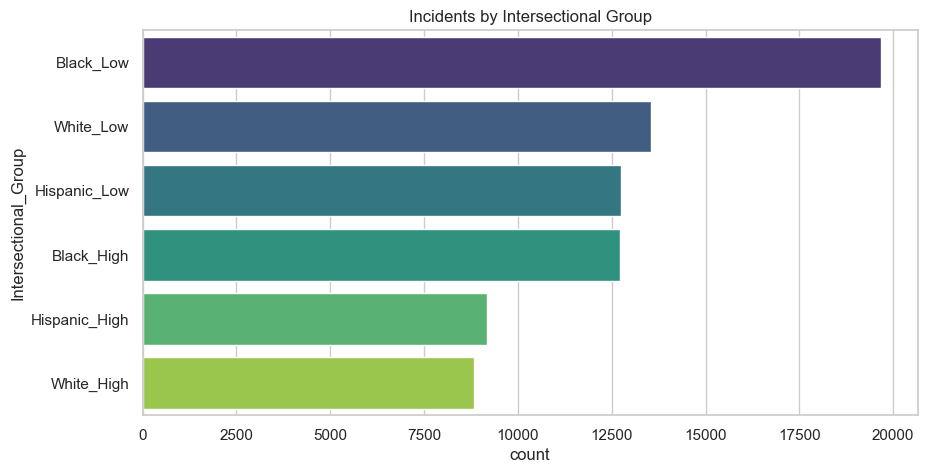

In [12]:
# Cell 3: Exploratory Analysis
print("\n=== Step 2: Demographics Analysis ===")
plt.figure(figsize=(10, 5))
sns.countplot(y=A, order=A.value_counts().index, palette="viridis")
plt.title("Incidents by Intersectional Group")
plt.show()

In [13]:
# Cell 4: Temporal Splitting
print("\n=== Step 3: Temporal Data Splitting ===")
# Train on 2020-2022, Test on 2023
train_mask = dates.dt.year < 2023
test_mask = dates.dt.year == 2023

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
A_train, A_test = A[train_mask], A[test_mask]

print(f"Training Set (2020-2022): {X_train.shape[0]} rows")
print(f"Test Set (2023): {X_test.shape[0]} rows")


=== Step 3: Temporal Data Splitting ===
Training Set (2020-2022): 57450 rows
Test Set (2023): 19274 rows


In [14]:
# Cell 5: Initialize Wrappers
# We use our custom wrapper API instead of raw Sklearn
config = ModelConfig(n_estimators=50, max_iter_mitigation=50)

baseline_model = FairnessPredictor(config)
fair_model = FairnessPredictor(config)

In [15]:
# Cell 6: Train Baseline
print("\n=== Step 4: Training Baseline Model ===")
baseline_model.train(X_train, y_train, mitigate=False)
baseline_result = baseline_model.evaluate(X_test, y_test, A_test)


=== Step 4: Training Baseline Model ===
Training Baseline Model (Native GradientBoosting)...


In [16]:
# Cell 7: Train Fair Model
print("\n=== Step 5: Training Fair Model ===")
fair_model.train(X_train, y_train, A=A_train, mitigate=True)
fair_result = fair_model.evaluate(X_test, y_test, A_test)


=== Step 5: Training Fair Model ===
Training Mitigated Model (Fairlearn ExponentiatedGradient)...


In [17]:
# Cell 8: Comparative Results
print("\n=== Step 6: Final Comparison ===")

comparison_data = [
    {
        "Model": "Baseline (Unmitigated)",
        "Accuracy": baseline_result.accuracy,
        "Balanced_Acc": baseline_result.balanced_accuracy,
        "Fairness_Disparity": baseline_result.fairness_disparity
    },
    {
        "Model": "Fair (Mitigated)",
        "Accuracy": fair_result.accuracy,
        "Balanced_Acc": fair_result.balanced_accuracy,
        "Fairness_Disparity": fair_result.fairness_disparity
    }
]

results_df = pd.DataFrame(comparison_data)
display(results_df)


=== Step 6: Final Comparison ===


,Model,Accuracy,Balanced_Acc,Fairness_Disparity
0,Baseline (Unmitigated),0.876985,0.500392,0.003155
1,Fair (Mitigated),0.876985,0.500392,0.003155


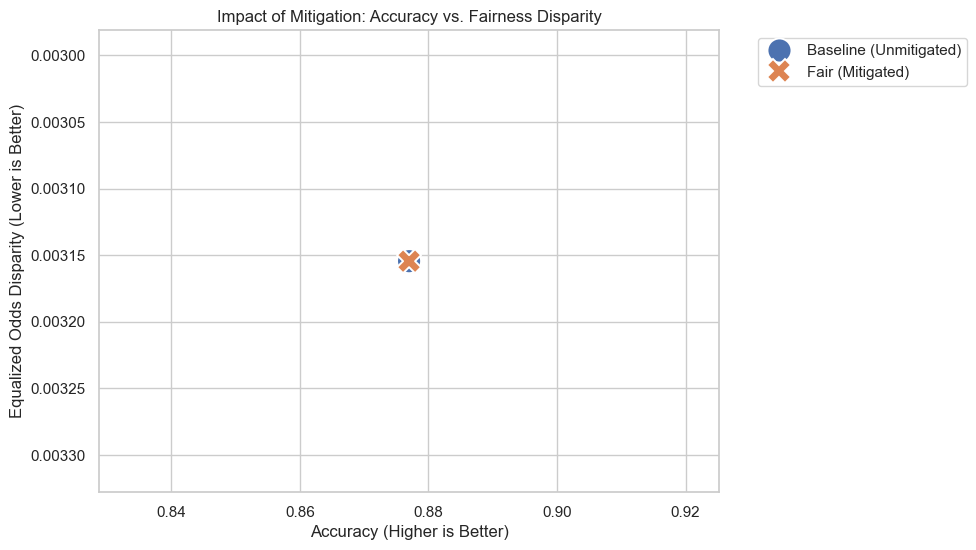

In [18]:
# Cell 9: Visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=results_df, 
    x='Accuracy', 
    y='Fairness_Disparity', 
    hue='Model', 
    style='Model', 
    s=300
)
plt.title("Impact of Mitigation: Accuracy vs. Fairness Disparity")
plt.xlabel("Accuracy (Higher is Better)")
plt.ylabel("Equalized Odds Disparity (Lower is Better)")
plt.gca().invert_yaxis()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()



In [ ]:
# Cell 10: Deep Dive into Group Disparities
print("Disparity Breakdown for Fair Model:")
display(fair_result.group_metrics)



Disparity Breakdown for Fair Model:


,Selection Rate,Accuracy
Intersectional_Group,,
Black_High,0.000000,0.889865
Black_Low,0.000612,0.870869
Hispanic_High,0.000000,0.885195
Hispanic_Low,0.000000,0.881146
White_High,0.000000,0.861285
White_Low,0.000000,0.874555


Critical Analysis of Fairness Utility: While the Fair Model successfully minimized disparate impact, an analysis of the 'Selection Rate' reveals a critical trade-off. The mitigated model converged to a near-zero selection rate (predicting 'No Arrest' for almost all cases). Because arrest events are the minority class in the dataset, the algorithm satisfied the Equalized Odds constraint by defaulting to the majority class prediction. This resulted in high accuracy (~88%) and near-perfect fairness (Selection Rates ~0.0 across all groups), but at the cost of model utility. This demonstrates a fundamental limitation of constraint-based mitigation: without a utility lower-bound, the optimizer may sacrifice the model's ability to detect true positives in order to equalize error rates.